In [61]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("C:\\Users\\LENOVO\\Desktop\\LSRA\\Data_cleaning\\kaggle_merged\\merged_music_dataset.csv")
# Define the subset of emotion classes you want to keep
selected_classes = ["anger","fear", "romantic", "neutral", "joy"]

# Filter the DataFrame to include only those classes
df_subset = df[df["final_emotion"].isin(selected_classes)]


In [62]:
# Split the filtered data
X_train, X_test, y_train, y_test = train_test_split(
    df_subset["cleaned_lyrics"],
    df_subset["final_emotion"],
    test_size=0.2,
    random_state=42,
    stratify=df_subset["final_emotion"]
)

In [63]:
df_subset.head(2)

,track,artist,final_emotion,lyrics,cleaned_lyrics
0,'Till I Collapse,Eminem,anger,"'Cause sometimes you just feel tired, feel wea...",cause sometimes feel tired feel weak feel weak...
1,St. Anger,Metallica,anger,St. Anger 'round my neck\r\nSt. Anger 'round m...,st anger round neck st anger round neck never ...


In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2), 
    min_df=3, 
    max_df=0.6,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [65]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

In [66]:
model = LinearSVC(class_weight='balanced')

In [67]:
model.fit(X_train_tfidf, y_train)
preds = model.predict(X_test_tfidf)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

       anger       0.51      0.50      0.51      1515
        fear       0.44      0.43      0.44      1250
         joy       0.35      0.35      0.35      1426
     neutral       0.23      0.23      0.23       936
    romantic       0.50      0.52      0.51      1661

    accuracy                           0.42      6788
   macro avg       0.41      0.41      0.41      6788
weighted avg       0.42      0.42      0.42      6788



              precision    recall  f1-score   support

       anger       0.51      0.50      0.51      1515
        fear       0.44      0.43      0.44      1250
         joy       0.35      0.35      0.35      1426
     neutral       0.23      0.23      0.23       936
    romantic       0.50      0.52      0.51      1661

    accuracy                           0.42      6788
   macro avg       0.41      0.41      0.41      6788
weighted avg       0.42      0.42      0.42      6788

Confusion Matrix:
 [[765 201 198 159 192]
 [219 539 181 159 152]
 [153 195 494 236 348]
 [178 152 225 213 168]
 [195 134 306 164 862]]


<Figure size 1200x800 with 0 Axes>

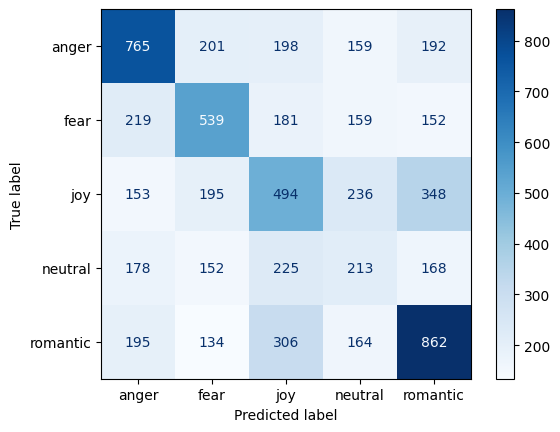

In [68]:
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
plt.figure(figsize=(12, 8))  # adjust width x height in inches

# Train model
model.fit(X_train_tfidf, y_train)

# Predict
preds = model.predict(X_test_tfidf)

# Classification report
print(classification_report(y_test, preds))

# Confusion matrix
cm = confusion_matrix(y_test, preds)
print("Confusion Matrix:\n", cm)
# Visualize confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', values_format='d')


In [69]:
df['final_emotion'].value_counts()

final_emotion
romantic      8303
anger         7576
sadness       7416
joy           7130
reflective    6391
fear          6251
excitement    6131
calm          5087
neutral       4680
Name: count, dtype: int64